### PCA DADOS DO AR

A ideia, nesse primeiro momento, é verificar se é possível aplicar o PCA nos dados atuais. Para isso, vamos nos basear nos resultados do KMO e do teste da esfericidade de Bartlett

#### OBSERVAÇÕES IMPORTANTES:
Nesse primeiro momento, selecionei somente as seguintes features para o PCA:
'hum', 'pm10', 'pm25', 'pm1', 'NO2', 'CO', 'NH3', 'intTemp', 'extTemp', 'alt', 'Pres'
Quanto aos dados nulos, apenas "dropei" todas as colunas com valores nulos, perdendo cerca de 60% dos dados totais, futuramente vou testar outra abordagem para o preenchimento dessas lacunas.
Apliquei o PCA sobre a Matriz de Correlação.

In [1]:
# Importação de bibliotecas necessárias
# Remova o '#' e execute a linha para instalar as bibliotecas
# !pip install factor_analyzer numpy pandas matplotlib seaborn scikit-learn scipy 

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from scipy.stats import chi2

from factor_analyzer.factor_analyzer import calculate_kmo
from factor_analyzer.factor_analyzer import calculate_bartlett_sphericity

In [2]:
USER_DIR = os.getcwd()  # Diretório atual
DATA_PATH = os.path.join(USER_DIR, 'data', 'moqa.csv')  # Caminho para os dados
data = pd.read_csv(DATA_PATH)  # Carregando os dados do arquivo CSV

#### Breve análise dos dados:

In [3]:
print(data.shape)  # Exibindo o tamanho do DataFrame
print(data.info())  # Exibindo informações sobre o DataFrame
print(data.describe())  # Exibindo estatísticas descritivas do DataFrame
print('Quantidade de nulos: ', data.isnull().sum())  # Exibindo a contagem de valores nulos por coluna

(3861652, 33)
<class 'pandas.DataFrame'>
RangeIndex: 3861652 entries, 0 to 3861651
Data columns (total 33 columns):
 #   Column                Dtype  
---  ------                -----  
 0   Unnamed: 0            int64  
 1   data_hora             str    
 2   createdTime           str    
 3   hum                   float64
 4   moqaID                str    
 5   alt                   float64
 6   pm25                  float64
 7   Pres                  float64
 8   CO                    float64
 9   O3                    float64
 10  NO2                   float64
 11  NH3                   float64
 12  pm10                  float64
 13  pm1                   float64
 14  intTemp               float64
 15  extTemp               float64
 16  pmsLog                int64  
 17  adsLog                int64  
 18  rtcLog                int64  
 19  bmeLog                int64  
 20  ccsLog                int64  
 21  msdLog                int64  
 22  erroLog               int64  
 23  Pont

In [4]:
data.head(10)  # Exibindo as primeiras 10 linhas do DataFrame

,Unnamed: 0,data_hora,createdTime,hum,moqaID,alt,pm25,Pres,CO,O3,...,Ponto,Zona,Latitude,Longitude,Bairro,Referência,Localizador Google,Status (Monitor),Infraestrutura MOB,Status (Transmissão)
0,0,2023-08-22 11:31:14+00:00,2023-08-22T14:46:28.139743Z,50.67538,DD34F0,12.24787,6.21875,101177.96875,NaN,NaN,...,3.0,North,-3.711826,-38.555781,Carlito Pamplona,Leste Oeste (EMEF Hilberto Silva),https://maps.app.goo.gl/XRJm32quHdo2HxuF9,Instalado,Concluído,Transmitindo (MOB)
1,1,2023-08-22 11:31:46+00:00,2023-08-22T14:46:56.045103Z,48.54282,DD34F0,12.16762,7.50000,101178.93750,NaN,NaN,...,3.0,North,-3.711826,-38.555781,Carlito Pamplona,Leste Oeste (EMEF Hilberto Silva),https://maps.app.goo.gl/XRJm32quHdo2HxuF9,Instalado,Concluído,Transmitindo (MOB)
2,2,2023-08-22 11:32:14+00:00,2023-08-22T14:47:23.798216Z,47.78475,DD34F0,12.29149,9.18750,101177.44531,NaN,NaN,...,3.0,North,-3.711826,-38.555781,Carlito Pamplona,Leste Oeste (EMEF Hilberto Silva),https://maps.app.goo.gl/XRJm32quHdo2HxuF9,Instalado,Concluído,Transmitindo (MOB)
3,3,2023-08-22 11:32:42+00:00,2023-08-22T14:47:51.820758Z,47.77321,DD34F0,12.44472,11.22656,101175.61719,NaN,NaN,...,3.0,North,-3.711826,-38.555781,Carlito Pamplona,Leste Oeste (EMEF Hilberto Silva),https://maps.app.goo.gl/XRJm32quHdo2HxuF9,Instalado,Concluído,Transmitindo (MOB)
4,4,2023-08-22 11:33:09+00:00,2023-08-22T14:48:19.477544Z,47.95964,DD34F0,12.49085,11.30000,101175.06250,NaN,NaN,...,3.0,North,-3.711826,-38.555781,Carlito Pamplona,Leste Oeste (EMEF Hilberto Silva),https://maps.app.goo.gl/XRJm32quHdo2HxuF9,Instalado,Concluído,Transmitindo (MOB)
5,5,2023-08-22 11:33:37+00:00,2023-08-22T14:48:47.264201Z,49.08266,DD34F0,12.57050,10.71354,101174.11719,NaN,NaN,...,3.0,North,-3.711826,-38.555781,Carlito Pamplona,Leste Oeste (EMEF Hilberto Silva),https://maps.app.goo.gl/XRJm32quHdo2HxuF9,Instalado,Concluído,Transmitindo (MOB)
6,6,2023-08-22 11:34:05+00:00,2023-08-22T14:49:14.991072Z,49.12064,DD34F0,12.67994,9.95536,101172.82031,NaN,NaN,...,3.0,North,-3.711826,-38.555781,Carlito Pamplona,Leste Oeste (EMEF Hilberto Silva),https://maps.app.goo.gl/XRJm32quHdo2HxuF9,Instalado,Concluído,Transmitindo (MOB)
7,7,2023-08-22 11:34:33+00:00,2023-08-22T14:49:46.120138Z,48.86996,DD34F0,12.85130,9.44141,101170.75781,NaN,NaN,...,3.0,North,-3.711826,-38.555781,Carlito Pamplona,Leste Oeste (EMEF Hilberto Silva),https://maps.app.goo.gl/XRJm32quHdo2HxuF9,Instalado,Concluído,Transmitindo (MOB)
8,8,2023-08-22 11:35:04+00:00,2023-08-22T14:50:13.772152Z,48.53812,DD34F0,13.01833,9.17014,101168.74219,NaN,NaN,...,3.0,North,-3.711826,-38.555781,Carlito Pamplona,Leste Oeste (EMEF Hilberto Silva),https://maps.app.goo.gl/XRJm32quHdo2HxuF9,Instalado,Concluído,Transmitindo (MOB)
9,9,2023-08-22 11:35:31+00:00,2023-08-22T14:50:41.462495Z,48.22467,DD34F0,13.14409,8.91277,101167.23438,NaN,NaN,...,3.0,North,-3.711826,-38.555781,Carlito Pamplona,Leste Oeste (EMEF Hilberto Silva),https://maps.app.goo.gl/XRJm32quHdo2HxuF9,Instalado,Concluído,Transmitindo (MOB)


In [5]:
data = data.drop(['Unnamed: 0', 'O3'], axis=1) # Removendo colunas desnecessárias do DataFrame (no caso O3 era uma coluna de NaN)
data.head()

,data_hora,createdTime,hum,moqaID,alt,pm25,Pres,CO,NO2,NH3,...,Ponto,Zona,Latitude,Longitude,Bairro,Referência,Localizador Google,Status (Monitor),Infraestrutura MOB,Status (Transmissão)
0,2023-08-22 11:31:14+00:00,2023-08-22T14:46:28.139743Z,50.67538,DD34F0,12.24787,6.21875,101177.96875,NaN,0.096762,NaN,...,3.0,North,-3.711826,-38.555781,Carlito Pamplona,Leste Oeste (EMEF Hilberto Silva),https://maps.app.goo.gl/XRJm32quHdo2HxuF9,Instalado,Concluído,Transmitindo (MOB)
1,2023-08-22 11:31:46+00:00,2023-08-22T14:46:56.045103Z,48.54282,DD34F0,12.16762,7.50000,101178.93750,NaN,0.084920,NaN,...,3.0,North,-3.711826,-38.555781,Carlito Pamplona,Leste Oeste (EMEF Hilberto Silva),https://maps.app.goo.gl/XRJm32quHdo2HxuF9,Instalado,Concluído,Transmitindo (MOB)
2,2023-08-22 11:32:14+00:00,2023-08-22T14:47:23.798216Z,47.78475,DD34F0,12.29149,9.18750,101177.44531,NaN,0.083098,NaN,...,3.0,North,-3.711826,-38.555781,Carlito Pamplona,Leste Oeste (EMEF Hilberto Silva),https://maps.app.goo.gl/XRJm32quHdo2HxuF9,Instalado,Concluído,Transmitindo (MOB)
3,2023-08-22 11:32:42+00:00,2023-08-22T14:47:51.820758Z,47.77321,DD34F0,12.44472,11.22656,101175.61719,NaN,0.077328,NaN,...,3.0,North,-3.711826,-38.555781,Carlito Pamplona,Leste Oeste (EMEF Hilberto Silva),https://maps.app.goo.gl/XRJm32quHdo2HxuF9,Instalado,Concluído,Transmitindo (MOB)
4,2023-08-22 11:33:09+00:00,2023-08-22T14:48:19.477544Z,47.95964,DD34F0,12.49085,11.30000,101175.06250,NaN,0.076418,NaN,...,3.0,North,-3.711826,-38.555781,Carlito Pamplona,Leste Oeste (EMEF Hilberto Silva),https://maps.app.goo.gl/XRJm32quHdo2HxuF9,Instalado,Concluído,Transmitindo (MOB)


In [6]:
# Selecionando 10 features para análise de PCA
pca_features = ['hum', 'pm10', 'pm25', 'pm1', 'NO2', 'CO', 'NH3', 'intTemp', 'extTemp', 'alt', 'Pres']
X = data[pca_features]  # Selecionando as features do DataFrame para PCA
X.isnull().sum()  # Verificando a quantidade de valores nulos nas features selecionadas
X.dropna(inplace=True)  # Removendo linhas com valores nulos

In [7]:
X.describe()  # Exibindo estatísticas descritivas das features selecionadas

,hum,pm10,pm25,pm1,NO2,CO,NH3,intTemp,extTemp,alt,Pres
count,806733.000000,806733.000000,806733.000000,806733.000000,806733.000000,806733.000000,806733.000000,806733.000000,806733.000000,806733.000000,806733.000000
mean,46.211372,8.163023,6.332094,3.041516,0.302011,31.220613,16.642058,28.244551,29.589897,25.134731,52395.272468
std,23.221934,6.774640,5.854615,3.817339,0.173020,10.707829,4.656780,12.867110,2.189211,268.404491,50461.940979
min,0.250000,0.000000,0.000000,0.000000,0.044838,0.054901,1.076141,-146.330060,22.150390,-20894.371090,0.010000
25%,37.959870,3.792580,2.608870,0.681450,0.138666,20.481232,13.609009,29.915120,27.908290,6.453620,1007.553750
50%,50.023190,6.564520,4.851850,1.889550,0.293831,31.304138,16.624207,31.539990,29.011200,23.405990,100734.671880
75%,63.023430,10.498210,8.219350,3.960370,0.472984,42.645325,20.324677,35.084500,31.437060,36.675540,101073.828120
max,100.000000,263.171880,201.421880,106.171100,1.464401,49.992706,49.745697,136.337480,37.659550,25564.072270,986933.437500


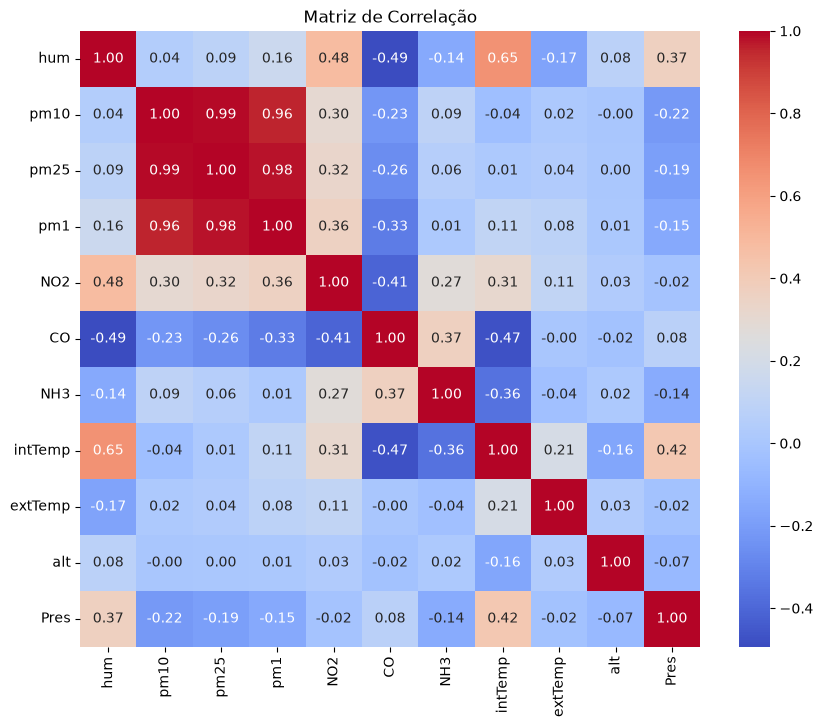

In [8]:
# Plotando a matriz de correlação das features selecionadas
corr = X.corr() # Essa função é muito massa kkkkkk, agiliza MUITO o processo
plt.figure(figsize=(10, 8))

sns.heatmap(
    corr,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Matriz de Correlação")
plt.show()


#### Análise KMO e Esferecidade de Bartlett

In [13]:
def cronbach_alpha(X):
    k = X.shape[1]
    variancias = X.var(axis=0, ddof=1)
    soma_variancias = variancias.sum()
    soma_itens = X.sum(axis=1)
    variancia_total = soma_itens.var(ddof=1)
    alpha = (k / (k - 1)) * (
        1 - (soma_variancias / variancia_total)
    )
    
    return alpha

alpha = cronbach_alpha(X)

print(f"Alfa de Cronbach: {alpha:.4f}")

Alfa de Cronbach: -0.0004


In [9]:
# KMO
# Geral
kmo_all, kmo_model = calculate_kmo(X)
print(f"KMO: {kmo_model:.4f}")
# Individual
kmo_individual = pd.Series(
    kmo_all,
    index=X.columns
)
kmo_individual.sort_values(ascending=False)

# Como KMO > 0.5, está uma situação aceitável para realizar a PCA.

KMO: 0.5869


CO         0.672788
NO2        0.652328
pm1        0.642751
Pres       0.631501
intTemp    0.622085
pm10       0.614394
hum        0.598434
pm25       0.566069
NH3        0.440663
extTemp    0.149982
alt        0.145349
dtype: float64

In [10]:
# Esfericidade de Bartlett
chi_square_value, p_value = calculate_bartlett_sphericity(X)

print(f"Qui-quadrado: {chi_square_value:.4f}")
print(f"p-valor: {p_value:.6f}")

# Deu um resultado muito duvidoso KKKKKKKKKKKKKKK

Qui-quadrado: 9359569.7614
p-valor: 0.000000


In [11]:
# Implementação manual do teste de esfericidade de Bartlett
def teste_bartlett(X):
    n = X.shape[0]
    p = X.shape[1]
    R = X.corr()
    determinante = np.linalg.det(R)
    log_determinante = np.log(determinante)
    termo = (n - 1) - ((2 * p + 5) / 6)
    qui_quadrado = -termo * log_determinante
    gl = p * (p - 1) / 2
    p_valor = chi2.sf(qui_quadrado, gl)
    
    print("TESTE DE ESFERICIDADE DE BARTLETT")
    print(f"Número de observações (n): {n}")
    print(f"Número de variáveis (p): {p}")
    print(f"Determinante de R:        {determinante:.10e}")
    print(f"ln(|R|):                  {log_determinante:.10f}")
    print(f"Termo da fórmula:         {termo:.4f}")
    print(f"Qui-quadrado:             {qui_quadrado:.4f}")
    print(f"Graus de liberdade:       {gl:.0f}")
    print(f"p-valor:                  {p_valor:.10e}")
    
    return qui_quadrado, gl, p_valor

In [12]:
chi2_manual, gl, p_manual = teste_bartlett(X)

print(f"Qui-quadrado: {chi2_manual:.4f}")
print(f"Graus de liberdade: {gl}")
print(f"p-valor: {p_manual:.10e}")

TESTE DE ESFERICIDADE DE BARTLETT
Número de observações (n): 806733
Número de variáveis (p): 11
Determinante de R:        9.1487116210e-06
ln(|R|):                  -11.6018974950
Termo da fórmula:         806727.5000
Qui-quadrado:             9359569.7614
Graus de liberdade:       55
p-valor:                  0.0000000000e+00
Qui-quadrado: 9359569.7614
Graus de liberdade: 55.0
p-valor: 0.0000000000e+00
